In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import stats
from astropy.table import Table

import matplotlib.pyplot as plt

In [22]:
A_per_pix = 0.0166

In [2]:
def to_array_or_nan(x, n=4):
    if isinstance(x, np.ndarray):
        return x
    else:
        return np.full(n, np.nan)

def prepare_data(data_file, m1=-1, m2=30):
    ata = pd.read_csv(data_file)
    ata['TOTCORR2'] = ata['TOTCORR'].str.split().apply(lambda x: np.array(x, dtype=float))
    ata['TOTCORR2_fixed'] = ata['TOTCORR2'].apply(to_array_or_nan)
    new_cols = ['TOTCORR_1', 'TOTCORR_2', 'TOTCORR_3', 'TOTCORR_4']
    ata[new_cols] = pd.DataFrame(ata['TOTCORR2_fixed'].tolist(), index=ata.index)
    # add a "sum" column
    ata['TOTCORR_SUM'] = ata[new_cols].sum(axis=1, min_count=4)

    # apply masks 
    date_mask = ata['MJD-OBS'] > max(ata['MJD-OBS']) - 765
    no_short_exp_mask = ata['EXPTIME'] > 10
    magmask = (ata['GAIAMAG'] > m1) & (ata['GAIAMAG'] <= m2)
    magmask2 = (ata['GAIAMAG'] > 9.2) & (ata['GAIAMAG'] < 9.5) #because of missing labeling in OBs, this was a default value, so remove all stars with this value as the data is not usable.
    count_range = (ata['TOTCORR_SUM'] > 0) & (ata['TOTCORR_SUM'] < 2*10**9)

    ata = ata[date_mask&no_short_exp_mask&magmask&~magmask2&count_range]
    return ata

In [3]:
data_file = 'data/Feb2026.csv'
data = prepare_data(data_file)
bright = prepare_data(data_file, m1=-1, m2=5.3)
faint = prepare_data(data_file, m1=5.3, m2=30)
len(data), len(bright), len(faint)

(7104, 3580, 3524)

In [4]:
# KPF-etc limits:
#- Teff: 2700 - 6600 Kelvin
#- Vmag: 2 - 19
#- Texp: 10 - 3600 seconds

validTeff_mask = (data['TARGTEFF'] > 2700) & (data['TARGTEFF'] < 6600)
invalidTeff = data[~validTeff_mask]
print(len(data), len(invalidTeff), len(invalidTeff)/len(data))

7104 245 0.034487612612612614


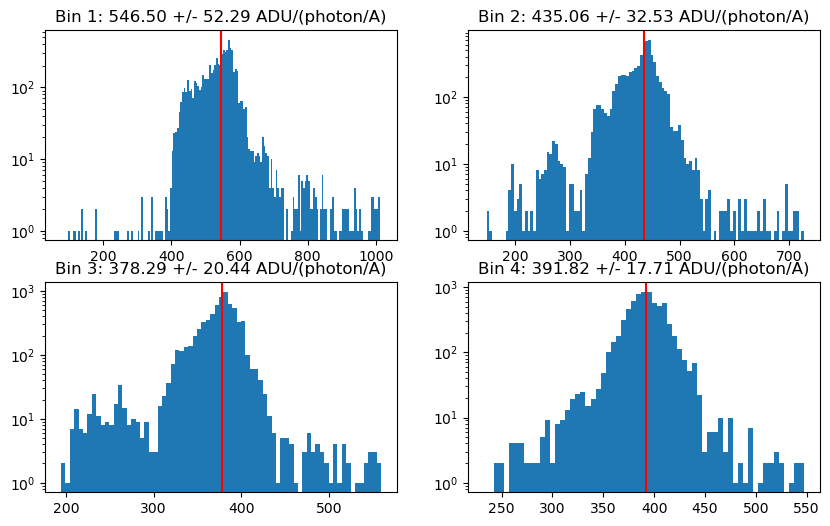

In [88]:
# WAVEBINS: 498.12 604.38 710.62 816.88

photons = {1: ( (data['SNRSC452'].values)**2 + (data['SNRSC548'].values)**2 )/2, # photons / pix
           2: (data['SNRSC652'].values)**2,
           3: (data['SNRSC747'].values)**2,
           4: (data['SNRSC852'].values)**2}

EM_ADU_for_1photon_per_pix = {}
EM_ADU_for_1photon_per_A = {}
photon_per_A_per_ADU = {}

plt.figure(figsize=(10,6))

for i in [1, 2, 3, 4]:
    plt.subplot(2,2,i)
    ADU_per_photon = data[f'TOTCORR_{i}']/photons[i]
    mean, median, stddev = stats.sigma_clipped_stats(ADU_per_photon)
    bins = np.arange(median-9*stddev, median+9*stddev, 5)
    plt.title(f'Bin {i}: {median:.2f} +/- {stddev:.2f} ADU/(photon/A)')
    plt.hist(ADU_per_photon, bins=bins, log=True)
    plt.axvline(median, color='r')
    EM_ADU_for_1photon_per_pix[i] = float(median)
    EM_ADU_for_1photon_per_A[i] = float(median)/A_per_pix
    photon_per_A_per_ADU[i] = A_per_pix/float(median)

plt.show()

In [89]:
EM_ADU_for_1photon_per_pix

{1: 546.4976319023256,
 2: 435.0551931505991,
 3: 378.29337370478606,
 4: 391.8194711440336}

In [90]:
    # photons/A near bin center divided by TOTCORR --> photons/A / ADU
    # bin1 / 498.125nm = 0.104 (1.4%)
    # bin2 / 604.375nm = 0.116 (0.8%)
    # bin3 / 710.625nm = 0.087 (2.2%)
    # bin4 / 816.875nm = 0.116 (0.8%)

photon_per_A_per_ADU

{1: 3.0375245986366662e-05,
 2: 3.8156078266266615e-05,
 3: 4.3881286731060657e-05,
 4: 4.236644991513912e-05}

In [103]:
for wbin in [1, 2, 3, 4]:
    print(photon_per_A_per_ADU[wbin]/photon_per_A_per_ADU[1]*0.104)

0.104
0.1306403293482065
0.15024253044991356
0.14505597067928488
